In [11]:
import numpy as np 
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt 
outdir = '/mnt/home/awakhloo/ceph/persistent-oscillations/results'
figdir = '/mnt/home/awakhloo/ceph/persistent-oscillations/figs'

In [12]:
# np.random.seed(23453)
np.random.seed(97537)
n = 400 
T = 1000 
halt = 400 
init = 100
g = 1.3
p = 25
I = 0.65
omega = 0.1 * 2*np.pi
# k_vals = [0.5, 2.8, .5]
k_vals = [0., 2.8, 0.]
delt = 300 
k_intvs = [[0,init],  [init, halt+delt], [halt+delt, T]]
phi = np.tanh

J = g/np.sqrt(n) * np.random.randn(n,n) 
thetas = np.random.uniform(low=0,high=2*np.pi,size=(n,))

x0 = np.random.randn(n) / np.sqrt(n) 
A0 = np.zeros(n**2)
Y0 = np.concatenate([x0, A0]) 

dt= 0.1 
t_eval = np.linspace(0,T,int(T/dt) )

In [13]:
def dxdt(t,x,J,A,phi,inp_fn):
    return -x + (J+A)@phi(x) +  inp_fn(t)

def dAdt(t,A,x,k,p,n,phi): 
    return (-A + k/n * np.outer(phi(x), phi(x)))/p

def dfdt(t,Y,inp_fn,k_vals,k_intvs,p,n,J,phi):
    x, A = Y[:n], Y[n:].reshape(n,n)
    k = get_kval(t, k_vals, k_intvs)
    dx = dxdt(t,x,J,A,phi,inp_fn)
    dA = dAdt(t,A=A,x=x,k=k,p=p,n=n,phi=phi)
    return np.concatenate([dx, dA.reshape(-1)])

def make_halt_osc(I, omega, thetas, halt, init): 
    def ipfn(t): 
        return I * np.cos(omega * t + thetas) * (t <= halt) * (t >= init) 
    return ipfn 

def get_kval(t,k_vals,k_intvs): 
    for i, (s, e) in enumerate(k_intvs): 
        if t >= s and t <= e : 
            return k_vals[i] 
    else: 
        print(t)


In [14]:
inp_fn = make_halt_osc(I, omega, thetas, halt, init) 
ode = lambda t, Y: dfdt(t,Y,inp_fn=inp_fn,k_vals=k_vals,k_intvs=k_intvs,p=p,n=n,J=J,phi=phi)
soln = solve_ivp(ode, (0,T), Y0, t_eval=t_eval) 
t, y = soln.t, soln.y 
x, A = y[:n], y[n:].reshape(n,n,y.shape[-1])

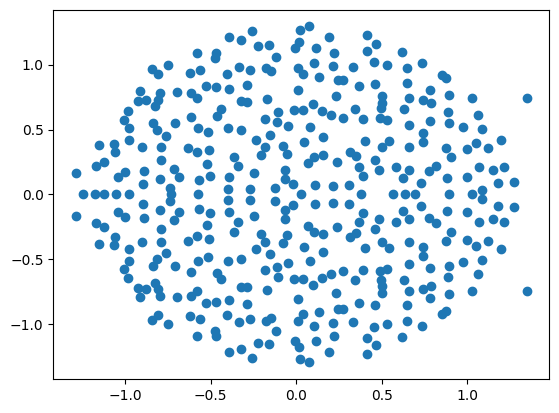

In [15]:
W = J + A[..., int(halt/dt)] 
eigs = np.linalg.eigvals(W) 
plt.scatter(eigs.real, eigs.imag)

In [17]:
resc={'xc' : x, 't' : t, 'halt' : halt, 'k_intvs' : k_intvs}
np.save(outdir + '/go_back_to_chaos.npy', resc)

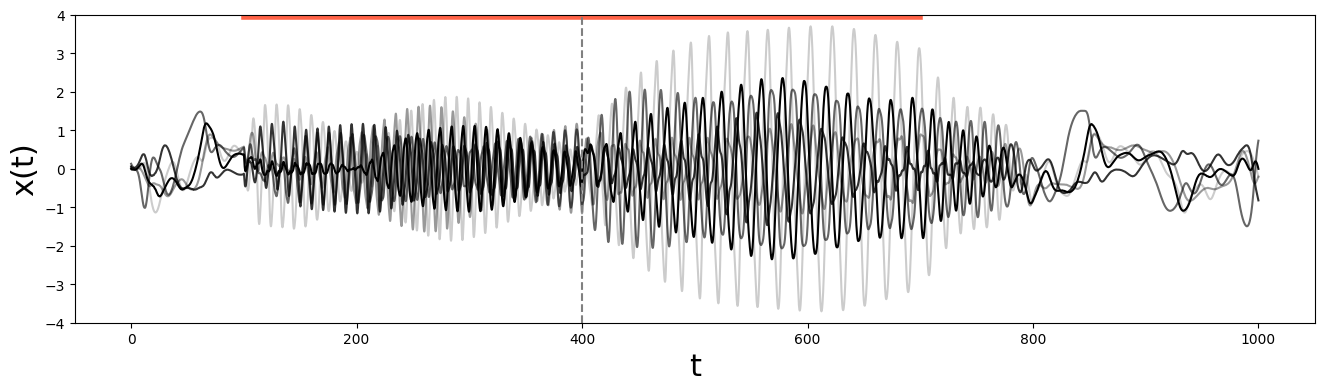

In [18]:
def make_go_back_fig(res, ax): 
    fn = 22 
    x, t, halt, k_intvs = res['xc'], res['t'], res['halt'], res['k_intvs']
    for i in range(5):
        # ax.plot(t-halt,x[i],color='k', alpha=0.2*(i+1))
        ax.plot(t,x[i],color='k', alpha=0.2*(i+1))
    ylim = ax.get_ylim() 
    X = np.linspace(k_intvs[1][0],k_intvs[1][1],100) # - halt 
    ax.plot(X, 3.93 * np.ones(len(X)), color='tomato', lw=4)
    ylim = [-4,4]
    ax.set_ylim(ylim)
    # ax.vlines(0, ylim[0],ylim[1], ls='--', color='grey')
    ax.vlines(halt, ylim[0],ylim[1], ls='--', color='grey')
    ax.set_ylim(ylim)
    ax.set_xlabel("t", fontsize=fn) 
    ax.set_ylabel("x(t)", fontsize=fn) 

fig, ax = plt.subplots(figsize=(16,4))
make_go_back_fig(resc, ax)
fig.savefig(figdir + '/sm_figs/modulate.png', dpi=300, bbox_inches='tight')

In [19]:
import sys
import os 
from tqdm import tqdm
import jax.numpy as jnp

sys.path.append(os.getcwd()) 
import meanfield.hebbian_meanfield as mf

In [52]:
np.random.seed(9876)
# params 
k =2.5
p = 100 
I = 3#3.
g = 1.3 

# time params 
T = 200
dt = 0.1
halt_time = 1/2
tvec = np.linspace(0,T,int(T/dt)) 
halt = T * halt_time
flip = T * halt_time / 2  # time to flip to other eigvec 
A_times = [T * halt_time]
# sim params
N = 500
Nsave = N
Nbatch = 5000

# solver params
rtol, atol=1e-6, 1e-6

# target  
targ = 0.9 + 0.8j
n_sub = 1 # num batch to save

# draw the random params: init and connectivity
params = {
          'g' : g, 'I' : I,  'k' : k, 
          'p' : p, 'omega' : None, 
          'T' : T, 'halt_time' : halt_time, 
        'halt' : T * halt_time,
         }
params['J'] = g/np.sqrt(N) * np.random.randn(N,N)
params['Y0'] = jnp.concatenate([np.random.randn(N), np.zeros(N**2)]) 
params['thetas'] = np.random.uniform(low=0,high=2*np.pi,size=(N,))

# get the target and define input 
eigs, evecs = np.linalg.eig(params['J'])
ind = np.argmin(np.abs(eigs - targ))
e = evecs[:,ind]
u, v = e.real, e.imag 
def targ_inp(t): 
    out= I * np.sqrt(N) *  u 
    out= jnp.where(t<flip, out, I * np.sqrt(N) * v)
    out_mask = jnp.where(t<halt,  out, 0 )
    return out_mask
# solve 
Xh, A = mf.solve_cust_system(params, targ_inp, T=T, N=N, Nsave=Nsave, rtol=rtol,
                          atol=atol, dt_eval=dt, A_times=A_times)

# np.save(outpath + '/binary_results.npy', 
#         {'eigs' : all_eigs, 'target_times' : A_times, 'target' : targ})

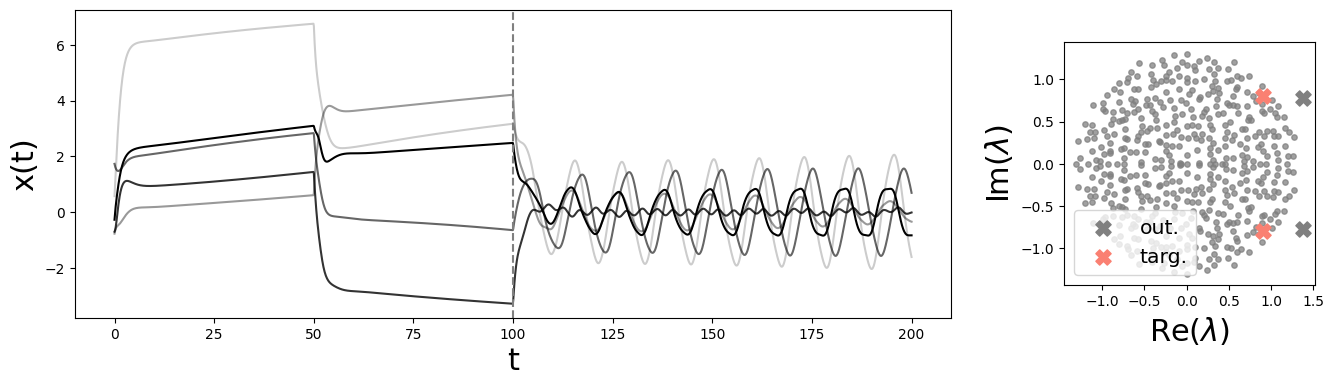

In [53]:
def make_flat_fig(t,x,W,targ, ax,s=15): 
    fn = 22 
    for i in range(5):
        ax[0].plot(t,x[:,i],color='k', alpha=0.2*(i+1))
    ylim=ax[0].get_ylim()
    ax[0].vlines(halt, ylim[0],ylim[1], ls='--', color='grey')
    ax[0].set_ylim(ylim)
    ax[0].set_xlabel("t", fontsize=fn) 
    ax[0].set_ylabel("x(t)", fontsize=fn) 
    
    eigs = np.linalg.eigvals(W)
    ax[1].scatter(eigs.real,eigs.imag,c='grey',alpha=0.75, s=s)
    out = eigs[eigs.real.argmax()]
    scale=8
    ax[1].scatter(out.real,out.imag,s=scale*s,marker='X',c='grey')
    ax[1].scatter(out.real,-out.imag,s=scale*s,marker='X',c='grey',label='out.')
    ax[1].scatter(targ.real,targ.imag,s=scale*s,marker='X',c='salmon',label='targ.')
    ax[1].scatter(targ.real,-targ.imag,s=scale*s,marker='X',c='salmon')
    ax[1].set_aspect(1) 
    ax[1].set_xlabel(r"Re($\lambda$)",fontsize=fn) 
    ax[1].legend(fontsize=fn*2/3,loc='lower left')
    ax[1].set_ylabel(r"Im($\lambda$)",fontsize=fn) 

fig, ax = plt.subplots(1,2,figsize=(16,4),width_ratios=[3.5,1])
make_flat_fig(tvec,Xh, params['J'] + A.squeeze(),targ, ax)
fig.savefig(figdir + '/sm_figs/biphasic.png', dpi=300, bbox_inches='tight')